In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import joblib
import os
import time
from sklearn.model_selection import train_test_split, KFold
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

df = pd.read_parquet('/content/drive/MyDrive/Dissertation/Data/phase2_features.parquet')
feature_cols = joblib.load('/content/drive/MyDrive/Dissertation/Data/feature_names.pkl')
print(f"Loaded {len(df):,} rows")

Mounted at /content/drive
Loaded 363,250 rows


In [ ]:
model_features = [c for c in feature_cols if c != 'price_per_sqm']
df_model = df.dropna(subset=model_features + ['log_price']).copy()

X = df_model[model_features]
y = df_model['log_price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {len(X_train):,} | Test: {len(X_test):,}")

Train: 289,348 | Test: 72,337


In [1]:
ridge = Ridge(alpha=1.0, random_state=42)
ridge.fit(X_train_scaled, y_train)

y_pred_test = ridge.predict(X_test_scaled)
test_r2 = r2_score(y_test, y_pred_test)
rmse_pounds = np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_pred_test)))
mae_pounds = mean_absolute_error(np.exp(y_test), np.exp(y_pred_test))

print(f"Ridge — Test R²: {test_r2:.4f}, RMSE: £{rmse_pounds:,.0f}, MAE: £{mae_pounds:,.0f}")

os.makedirs('/content/drive/MyDrive/Dissertation/Models', exist_ok=True)
joblib.dump(ridge, '/content/drive/MyDrive/Dissertation/Models/ridge_baseline.pkl')
joblib.dump(scaler, '/content/drive/MyDrive/Dissertation/Models/scaler.pkl')

NameError: name 'Ridge' is not defined

In [ ]:
start_time = time.time()
rf = RandomForestRegressor(n_estimators=200, max_depth=None, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
print(f"Training took {(time.time()-start_time)/60:.1f} minutes")

y_pred_test_rf = rf.predict(X_test)
test_r2_rf = r2_score(y_test, y_pred_test_rf)
rmse_pounds_rf = np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_pred_test_rf)))
mae_pounds_rf = mean_absolute_error(np.exp(y_test), np.exp(y_pred_test_rf))

print(f"Random Forest — Test R²: {test_r2_rf:.4f}, RMSE: £{rmse_pounds_rf:,.0f}, MAE: £{mae_pounds_rf:,.0f}")
joblib.dump(rf, '/content/drive/MyDrive/Dissertation/Models/random_forest.pkl')

Training took 4.3 minutes
Random Forest — Test R²: 0.7924, RMSE: £75,228, MAE: £39,968


['/content/drive/MyDrive/Dissertation/Models/random_forest.pkl']

In [ ]:
!pip install optuna --quiet
import optuna
import xgboost as xgb
optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 10),
        'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist', 'early_stopping_rounds': 20
    }
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmses = []
    for tr_idx, val_idx in kf.split(X_train):
        Xtr, Xval = X_train.iloc[tr_idx], X_train.iloc[val_idx]
        ytr, yval = y_train.iloc[tr_idx], y_train.iloc[val_idx]
        m = xgb.XGBRegressor(**params)
        m.fit(Xtr, ytr, eval_set=[(Xval, yval)], verbose=False)
        rmses.append(np.sqrt(mean_squared_error(yval, m.predict(Xval))))
    return np.mean(rmses)

study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study.optimize(objective, n_trials=20, show_progress_bar=True)

best_params = study.best_params
best_params.update({'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist'})
xgb_model = xgb.XGBRegressor(**best_params)
xgb_model.fit(X_train, y_train)

y_pred_test_xgb = xgb_model.predict(X_test)
r2_xgb = r2_score(y_test, y_pred_test_xgb)
rmse_pounds_xgb = np.sqrt(mean_squared_error(np.exp(y_test), np.exp(y_pred_test_xgb)))
mae_pounds_xgb = mean_absolute_error(np.exp(y_test), np.exp(y_pred_test_xgb))

print(f"XGBoost — Test R²: {r2_xgb:.4f}, RMSE: £{rmse_pounds_xgb:,.0f}, MAE: £{mae_pounds_xgb:,.0f}")
print(f"Best params: {best_params}")

joblib.dump(xgb_model, '/content/drive/MyDrive/Dissertation/Models/xgb_model.pkl')
joblib.dump(best_params, '/content/drive/MyDrive/Dissertation/Models/xgb_best_params.pkl')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 264.7/264.7 kB 12.9 MB/s eta 0:00:00


  0%|          | 0/20 [00:00<?, ?it/s]

XGBoost — Test R²: 0.7983, RMSE: £73,881, MAE: £39,294
Best params: {'n_estimators': 499, 'max_depth': 7, 'learning_rate': 0.1763588669869222, 'subsample': 0.996369044503578, 'colsample_bytree': 0.8278354833331507, 'reg_alpha': 3.6096310789404593, 'reg_lambda': 3.9046558437874657, 'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist'}


['/content/drive/MyDrive/Dissertation/Models/xgb_best_params.pkl']

In [ ]:
reliable_districts = df['postcode_district'].value_counts()[df['postcode_district'].value_counts() >= 30].index
df_idx = df[df['postcode_district'].isin(reliable_districts)].copy()

monthly_ppsqm = df_idx.groupby(['postcode_district', 'sale_year', 'sale_month'])['price_per_sqm'].median().reset_index()
monthly_ppsqm = monthly_ppsqm.sort_values(['postcode_district', 'sale_year', 'sale_month'])
monthly_ppsqm['smoothed_ppsqm'] = monthly_ppsqm.groupby('postcode_district')['price_per_sqm'].transform(
    lambda s: s.rolling(window=3, min_periods=1, center=True).median())

latest_year = monthly_ppsqm['sale_year'].max()
latest_month = monthly_ppsqm[monthly_ppsqm['sale_year'] == latest_year]['sale_month'].max()

def get_nearest_reference(group):
    group = group.sort_values(['sale_year', 'sale_month']).reset_index(drop=True)
    group['period_num'] = group['sale_year'] * 12 + group['sale_month']
    target = latest_year * 12 + latest_month
    group['dist_to_target'] = (group['period_num'] - target).abs()
    return group.loc[group['dist_to_target'].idxmin(), 'smoothed_ppsqm']

reference_ppsqm = monthly_ppsqm.groupby('postcode_district').apply(get_nearest_reference, include_groups=False).reset_index()
reference_ppsqm.columns = ['postcode_district', 'reference_ppsqm']
monthly_ppsqm = monthly_ppsqm.merge(reference_ppsqm, on='postcode_district', how='left')
monthly_ppsqm['adj_factor'] = monthly_ppsqm['reference_ppsqm'] / monthly_ppsqm['smoothed_ppsqm']

df_idx = df_idx.merge(monthly_ppsqm[['postcode_district', 'sale_year', 'sale_month', 'adj_factor']],
                       on=['postcode_district', 'sale_year', 'sale_month'], how='left')
df_idx['adjusted_price'] = df_idx['price'] * df_idx['adj_factor']
df_idx['adjusted_log_price'] = np.log(df_idx['adjusted_price'])

model_cols_adj = model_features + ['adjusted_log_price']
df_model_adj = df_idx.dropna(subset=model_cols_adj).copy()
X_adj = df_model_adj[model_features]
y_adj = df_model_adj['adjusted_log_price']
X_train_adj, X_test_adj, y_train_adj, y_test_adj = train_test_split(X_adj, y_adj, test_size=0.2, random_state=42)

print(f"Reference: {latest_year}-{latest_month:02d} | Districts: {df_idx['postcode_district'].nunique()}/89 | Rows: {len(df_idx):,} | Missing: {df_idx['adj_factor'].isna().sum()}")
print(f"Adjusted train: {len(X_train_adj):,} | test: {len(X_test_adj):,}")

Reference: 2026-03 | Districts: 89/89 | Rows: 363,245 | Missing: 0
Adjusted train: 289,347 | test: 72,337


In [ ]:
scaler_adj = StandardScaler()
X_train_adj_scaled = scaler_adj.fit_transform(X_train_adj)
X_test_adj_scaled = scaler_adj.transform(X_test_adj)

ridge_adj = Ridge(alpha=1.0, random_state=42)
ridge_adj.fit(X_train_adj_scaled, y_train_adj)
test_r2_ridge_adj = r2_score(y_test_adj, ridge_adj.predict(X_test_adj_scaled))
print(f"Ridge (adjusted) — Test R²: {test_r2_ridge_adj:.4f}")

start_time = time.time()
rf_adj = RandomForestRegressor(n_estimators=200, max_depth=None, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_adj.fit(X_train_adj, y_train_adj)
print(f"RF training took {(time.time()-start_time)/60:.1f} minutes")
test_r2_rf_adj = r2_score(y_test_adj, rf_adj.predict(X_test_adj))
print(f"Random Forest (adjusted) — Test R²: {test_r2_rf_adj:.4f}")

Ridge (adjusted) — Test R²: 0.6650
RF training took 4.2 minutes
Random Forest (adjusted) — Test R²: 0.7638


In [ ]:
def objective_adj(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 10),
        'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist', 'early_stopping_rounds': 20
    }
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmses = []
    for tr_idx, val_idx in kf.split(X_train_adj):
        Xtr, Xval = X_train_adj.iloc[tr_idx], X_train_adj.iloc[val_idx]
        ytr, yval = y_train_adj.iloc[tr_idx], y_train_adj.iloc[val_idx]
        m = xgb.XGBRegressor(**params)
        m.fit(Xtr, ytr, eval_set=[(Xval, yval)], verbose=False)
        rmses.append(np.sqrt(mean_squared_error(yval, m.predict(Xval))))
    return np.mean(rmses)

study_adj = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_adj.optimize(objective_adj, n_trials=20, show_progress_bar=True)

best_params_adj = study_adj.best_params
best_params_adj.update({'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist'})
xgb_model_adj = xgb.XGBRegressor(**best_params_adj)
xgb_model_adj.fit(X_train_adj, y_train_adj)

y_pred_test_xgb_adj = xgb_model_adj.predict(X_test_adj)
test_r2_xgb_adj = r2_score(y_test_adj, y_pred_test_xgb_adj)
print(f"XGBoost (adjusted) — Test R²: {test_r2_xgb_adj:.4f}")
print(f"Best params: {best_params_adj}")

joblib.dump(xgb_model_adj, '/content/drive/MyDrive/Dissertation/Models/xgb_model_adjusted.pkl')
joblib.dump(best_params_adj, '/content/drive/MyDrive/Dissertation/Models/xgb_best_params_adjusted.pkl')

  0%|          | 0/20 [00:00<?, ?it/s]

XGBoost (adjusted) — Test R²: 0.7760
Best params: {'n_estimators': 364, 'max_depth': 8, 'learning_rate': 0.21414672967929962, 'subsample': 0.9462521565327079, 'colsample_bytree': 0.8173799273070002, 'reg_alpha': 0.02370059826544635, 'reg_lambda': 2.8149299498882714, 'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist'}


['/content/drive/MyDrive/Dissertation/Models/xgb_best_params_adjusted.pkl']

In [ ]:
test_adj_factors = df_idx.loc[X_test_adj.index, 'adj_factor'].values

y_pred_realterms = np.exp(y_pred_test_xgb_adj) / test_adj_factors
y_test_realterms = np.exp(y_test_adj) / test_adj_factors

rmse_realterms = np.sqrt(mean_squared_error(y_test_realterms, y_pred_realterms))
mae_realterms = mean_absolute_error(y_test_realterms, y_pred_realterms)
mape_realterms = np.mean(np.abs(y_test_realterms - y_pred_realterms) / y_test_realterms) * 100

print("=== XGBoost error, converted back to real sale-date £ terms ===")
print(f"RMSE: £{rmse_realterms:,.0f}")
print(f"MAE:  £{mae_realterms:,.0f}")
print(f"MAPE: {mape_realterms:.2f}%")

=== XGBoost error, converted back to real sale-date £ terms ===
RMSE: £74,979
MAE:  £40,002
MAPE: 18.80%


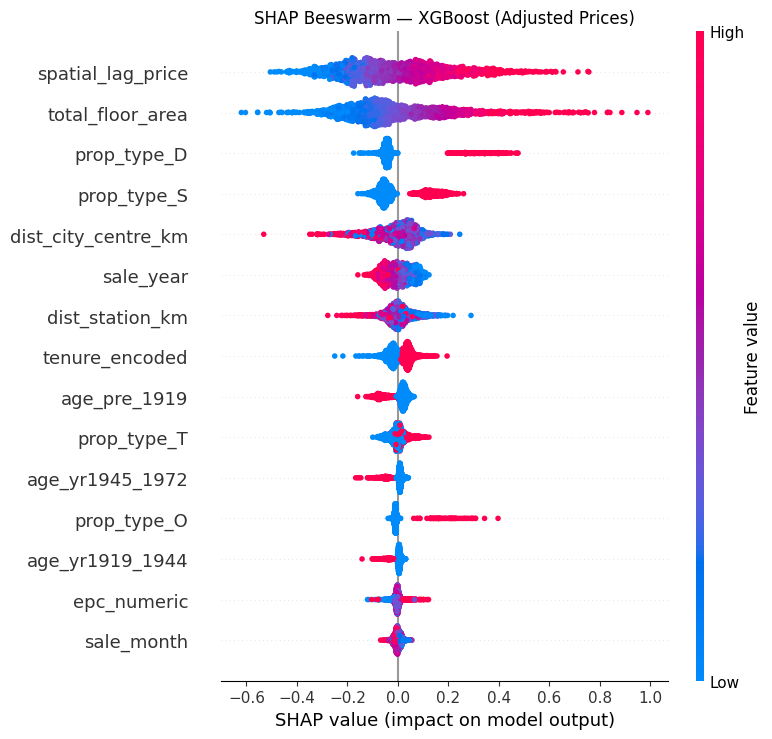

epc_numeric SHAP rank: 14 out of 18


In [ ]:
!pip install shap --quiet
import shap
import matplotlib.pyplot as plt

shap_sample_adj = X_test_adj.sample(n=2000, random_state=42)
explainer_adj = shap.TreeExplainer(xgb_model_adj)
shap_values_adj = explainer_adj.shap_values(shap_sample_adj)

fig, ax = plt.subplots(figsize=(10, 8))
shap.summary_plot(shap_values_adj, shap_sample_adj, feature_names=model_features, show=False, max_display=15)
plt.title('SHAP Beeswarm — XGBoost (Adjusted Prices)', fontsize=12)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Dissertation/Charts/shap_beeswarm_adjusted.png', dpi=150, bbox_inches='tight')
plt.show()

mean_abs_shap_adj = pd.Series(np.abs(shap_values_adj).mean(axis=0), index=model_features)
epc_rank_adj = mean_abs_shap_adj.rank(ascending=False)['epc_numeric']
print(f"epc_numeric SHAP rank: {int(epc_rank_adj)} out of {len(model_features)}")

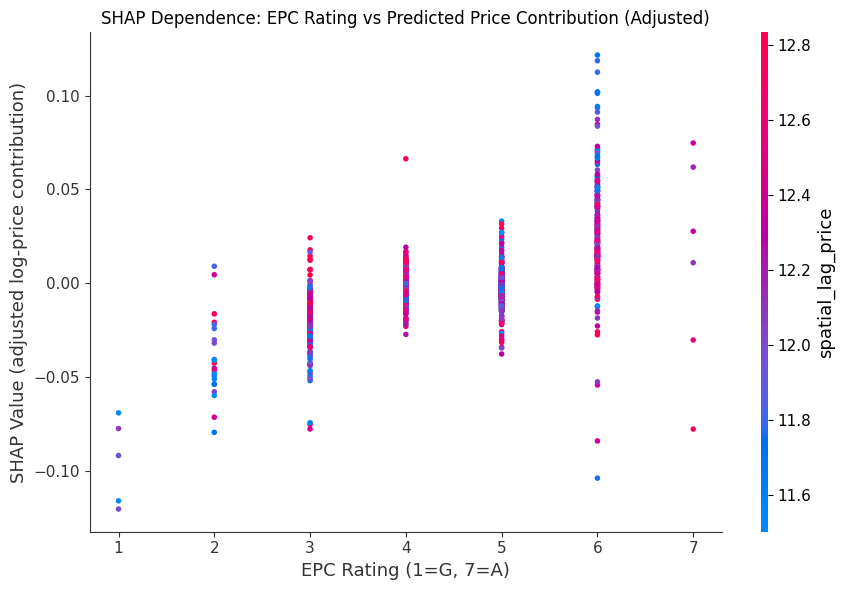

SHAP dependence plot saved.


In [ ]:
epc_idx = list(model_features).index('epc_numeric')
spatial_idx = list(model_features).index('spatial_lag_price')

fig, ax = plt.subplots(figsize=(9, 6))
shap.dependence_plot(epc_idx, shap_values_adj, shap_sample_adj,
                      feature_names=model_features, interaction_index=spatial_idx,
                      ax=ax, show=False)
ax.set_title('SHAP Dependence: EPC Rating vs Predicted Price Contribution (Adjusted)', fontsize=12)
ax.set_xlabel('EPC Rating (1=G, 7=A)')
ax.set_ylabel('SHAP Value (adjusted log-price contribution)')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Dissertation/Charts/shap_dependence_epc_adjusted.png', dpi=150, bbox_inches='tight')
plt.show()
print("SHAP dependence plot saved.")

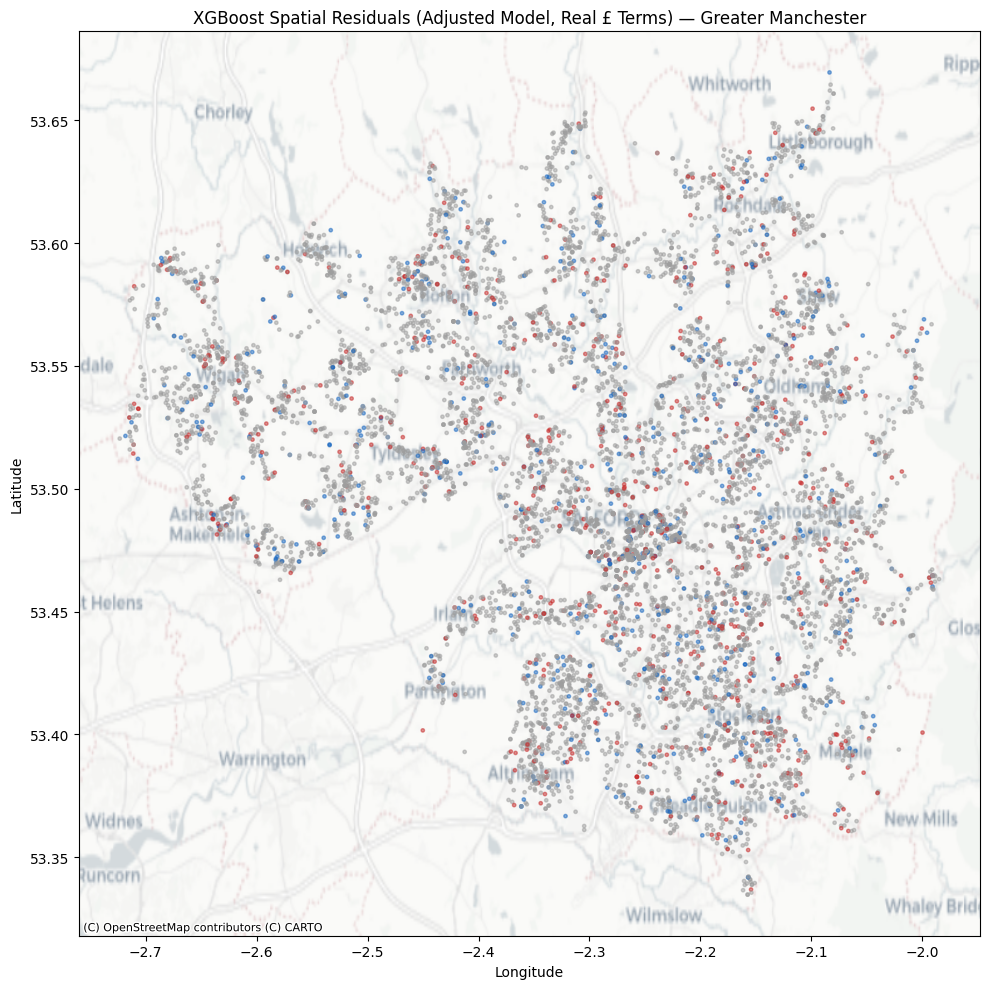

Overestimates (>0.3): 6,524
Underestimates (<-0.3): 5,380
Map saved.


In [ ]:
!pip install contextily --quiet
import contextily as cx

y_pred_test_xgb_adj_price = np.exp(y_pred_test_xgb_adj) / test_adj_factors
y_test_adj_price = np.exp(y_test_adj) / test_adj_factors
residuals_test_adj = np.log(y_pred_test_xgb_adj_price) - np.log(y_test_adj_price)

residual_df_adj = X_test_adj.copy()
residual_df_adj['residual'] = residuals_test_adj
residual_df_adj['latitude'] = df.loc[X_test_adj.index, 'latitude'].values
residual_df_adj['longitude'] = df.loc[X_test_adj.index, 'longitude'].values
residual_df_adj = residual_df_adj.dropna(subset=['latitude', 'longitude'])

sample_res_adj = residual_df_adj.sample(n=min(8000, len(residual_df_adj)), random_state=42)
colours_adj = sample_res_adj['residual'].apply(lambda r: '#C62828' if r > 0.3 else ('#1565C0' if r < -0.3 else '#9E9E9E'))

fig, ax = plt.subplots(figsize=(10, 10))
ax.scatter(sample_res_adj['longitude'], sample_res_adj['latitude'], c=colours_adj, s=6, alpha=0.5)
cx.add_basemap(ax, crs='EPSG:4326', source=cx.providers.CartoDB.Positron)
ax.set_title('XGBoost Spatial Residuals (Adjusted Model, Real £ Terms) — Greater Manchester', fontsize=12)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Dissertation/Charts/spatial_residual_map_adjusted.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Overestimates (>0.3): {(residuals_test_adj > 0.3).sum():,}")
print(f"Underestimates (<-0.3): {(residuals_test_adj < -0.3).sum():,}")
print("Map saved.")

In [ ]:
print("=" * 90)
print(f"{'MODEL':30} {'Test R2':>10} {'RMSE (£)':>12} {'MAE (£)':>12}")
print("=" * 90)
print(f"{'Ridge (nominal)':30} {test_r2:>10.4f} {rmse_pounds:>12,.0f} {mae_pounds:>12,.0f}")
print(f"{'Random Forest (nominal)':30} {test_r2_rf:>10.4f} {rmse_pounds_rf:>12,.0f} {mae_pounds_rf:>12,.0f}")
print(f"{'XGBoost (nominal)':30} {r2_xgb:>10.4f} {rmse_pounds_xgb:>12,.0f} {mae_pounds_xgb:>12,.0f}")
print("-" * 90)
print(f"{'Ridge (adjusted, index-terms)':30} {test_r2_ridge_adj:>10.4f} {'--':>12} {'--':>12}")
print(f"{'RF (adjusted, index-terms)':30} {test_r2_rf_adj:>10.4f} {'--':>12} {'--':>12}")
print(f"{'XGBoost (adjusted, index-terms)':30} {test_r2_xgb_adj:>10.4f} {'--':>12} {'--':>12}")
print("-" * 90)
print(f"{'XGBoost, real £ terms (final)':30} {'--':>10} {rmse_realterms:>12,.0f} {mae_realterms:>12,.0f}")
print(f"{'MAPE (real £ terms)':30} {'--':>10} {'--':>12} {mape_realterms:>11.2f}%")
print("=" * 90)

MODEL                             Test R2     RMSE (£)      MAE (£)
Ridge (nominal)                    0.7013      407,619       54,575
Random Forest (nominal)            0.7924       75,228       39,968
XGBoost (nominal)                  0.7983       73,881       39,294
------------------------------------------------------------------------------------------
Ridge (adjusted, index-terms)      0.6650           --           --
RF (adjusted, index-terms)         0.7638           --           --
XGBoost (adjusted, index-terms)     0.7760           --           --
------------------------------------------------------------------------------------------
XGBoost, real £ terms (final)          --       74,979       40,002
MAPE (real £ terms)                    --           --       18.80%


## EXPERIMENT — 3km Spatial Grid (Alternative to Postcode-District Indexing)

Tested per supervisor's suggestion of using a spatial grid instead of postcode districts for the price index. Density check showed 1km cells were far too sparse (median 4 sales/cell-month, 89.8% under 10 sales) and unusable; 3km cells were denser (median 22 sales/cell-month) and viable enough to test fully.

**Result:** XGBoost on the 3km-grid-adjusted target performed marginally worse than the postcode-district version - MAPE 19.17% vs 18.80%, RMSE £76,260 vs £74,979, MAE £41,259 vs £40,002.

**Conclusion:** Postcode-district indexing retained as final. Likely explanation: postcode districts align with real administrative and socioeconomic boundaries that influence price more directly than an arbitrary geographic grid. Cells below are kept for documentation of this experiment only - not used in the final model.

In [ ]:
grid_cell_size = 3
ref_lat = 53.4808
ref_lon = -2.2426
lat_km_per_deg = 110.57
lon_km_per_deg = 111.32 * np.cos(np.radians(ref_lat))

df_grid3 = df.dropna(subset=['latitude', 'longitude']).copy()
df_grid3['grid_x'] = ((df_grid3['longitude'] - ref_lon) * lon_km_per_deg / grid_cell_size).astype(int)
df_grid3['grid_y'] = ((df_grid3['latitude'] - ref_lat) * lat_km_per_deg / grid_cell_size).astype(int)
df_grid3['grid_id'] = df_grid3['grid_x'].astype(str) + '_' + df_grid3['grid_y'].astype(str)

reliable_grid3 = df_grid3['grid_id'].value_counts()[df_grid3['grid_id'].value_counts() >= 30].index
df_idx_grid3 = df_grid3[df_grid3['grid_id'].isin(reliable_grid3)].copy()

monthly_grid3 = df_idx_grid3.groupby(['grid_id', 'sale_year', 'sale_month'])['price_per_sqm'].median().reset_index()
monthly_grid3 = monthly_grid3.sort_values(['grid_id', 'sale_year', 'sale_month'])
monthly_grid3['smoothed_ppsqm'] = monthly_grid3.groupby('grid_id')['price_per_sqm'].transform(
    lambda s: s.rolling(window=3, min_periods=1, center=True).median())

def get_nearest_ref_grid3(group):
    group = group.sort_values(['sale_year', 'sale_month']).reset_index(drop=True)
    group['period_num'] = group['sale_year'] * 12 + group['sale_month']
    target = latest_year * 12 + latest_month
    group['dist_to_target'] = (group['period_num'] - target).abs()
    return group.loc[group['dist_to_target'].idxmin(), 'smoothed_ppsqm']

ref_grid3 = monthly_grid3.groupby('grid_id').apply(get_nearest_ref_grid3, include_groups=False).reset_index()
ref_grid3.columns = ['grid_id', 'reference_ppsqm']
monthly_grid3 = monthly_grid3.merge(ref_grid3, on='grid_id', how='left')
monthly_grid3['adj_factor'] = monthly_grid3['reference_ppsqm'] / monthly_grid3['smoothed_ppsqm']

df_idx_grid3 = df_idx_grid3.merge(monthly_grid3[['grid_id', 'sale_year', 'sale_month', 'adj_factor']],
                                   on=['grid_id', 'sale_year', 'sale_month'], how='left')
df_idx_grid3['adjusted_price'] = df_idx_grid3['price'] * df_idx_grid3['adj_factor']
df_idx_grid3['adjusted_log_price'] = np.log(df_idx_grid3['adjusted_price'])

model_cols_grid3 = model_features + ['adjusted_log_price']
df_model_grid3 = df_idx_grid3.dropna(subset=model_cols_grid3).copy()

X_grid3 = df_model_grid3[model_features]
y_grid3 = df_model_grid3['adjusted_log_price']
X_train_grid3, X_test_grid3, y_train_grid3, y_test_grid3 = train_test_split(X_grid3, y_grid3, test_size=0.2, random_state=42)

print(f"3km grid cells used: {df_idx_grid3['grid_id'].nunique()}")
print(f"Rows: {len(df_idx_grid3):,} | Missing adj_factor: {df_idx_grid3['adj_factor'].isna().sum()}")
print(f"Train: {len(X_train_grid3):,} | Test: {len(X_test_grid3):,}")

3km grid cells used: 124
Rows: 363,197 | Missing adj_factor: 0
Train: 289,324 | Test: 72,331


In [ ]:
scaler_grid3 = StandardScaler()
X_train_grid3_scaled = scaler_grid3.fit_transform(X_train_grid3)
X_test_grid3_scaled = scaler_grid3.transform(X_test_grid3)

ridge_grid3 = Ridge(alpha=1.0, random_state=42)
ridge_grid3.fit(X_train_grid3_scaled, y_train_grid3)
print(f"Ridge (3km grid) — Test R²: {r2_score(y_test_grid3, ridge_grid3.predict(X_test_grid3_scaled)):.4f}")

start_time = time.time()
rf_grid3 = RandomForestRegressor(n_estimators=200, max_depth=None, min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_grid3.fit(X_train_grid3, y_train_grid3)
print(f"RF training took {(time.time()-start_time)/60:.1f} minutes")
print(f"Random Forest (3km grid) — Test R²: {r2_score(y_test_grid3, rf_grid3.predict(X_test_grid3)):.4f}")

Ridge (3km grid) — Test R²: 0.6600
RF training took 4.3 minutes
Random Forest (3km grid) — Test R²: 0.7630


In [ ]:
def objective_grid3(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 3, 8),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda': trial.suggest_float('reg_lambda', 1, 10),
        'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist', 'early_stopping_rounds': 20
    }
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    rmses = []
    for tr_idx, val_idx in kf.split(X_train_grid3):
        Xtr, Xval = X_train_grid3.iloc[tr_idx], X_train_grid3.iloc[val_idx]
        ytr, yval = y_train_grid3.iloc[tr_idx], y_train_grid3.iloc[val_idx]
        m = xgb.XGBRegressor(**params)
        m.fit(Xtr, ytr, eval_set=[(Xval, yval)], verbose=False)
        rmses.append(np.sqrt(mean_squared_error(yval, m.predict(Xval))))
    return np.mean(rmses)

study_grid3 = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42))
study_grid3.optimize(objective_grid3, n_trials=20, show_progress_bar=True)

best_params_grid3 = study_grid3.best_params
best_params_grid3.update({'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist'})
xgb_model_grid3 = xgb.XGBRegressor(**best_params_grid3)
xgb_model_grid3.fit(X_train_grid3, y_train_grid3)

y_pred_test_grid3 = xgb_model_grid3.predict(X_test_grid3)
test_r2_grid3 = r2_score(y_test_grid3, y_pred_test_grid3)
print(f"XGBoost (3km grid, adjusted) — Test R²: {test_r2_grid3:.4f}")
print(f"Best params: {best_params_grid3}")

  0%|          | 0/20 [00:00<?, ?it/s]

XGBoost (3km grid, adjusted) — Test R²: 0.7754
Best params: {'n_estimators': 499, 'max_depth': 7, 'learning_rate': 0.1763588669869222, 'subsample': 0.996369044503578, 'colsample_bytree': 0.8278354833331507, 'reg_alpha': 3.6096310789404593, 'reg_lambda': 3.9046558437874657, 'random_state': 42, 'n_jobs': -1, 'tree_method': 'hist'}


In [ ]:
grid3_adj_factors = df_idx_grid3.loc[X_test_grid3.index, 'adj_factor'].values

y_pred_grid3_realterms = np.exp(y_pred_test_grid3) / grid3_adj_factors
y_test_grid3_realterms = np.exp(y_test_grid3) / grid3_adj_factors

rmse_grid3_realterms = np.sqrt(mean_squared_error(y_test_grid3_realterms, y_pred_grid3_realterms))
mae_grid3_realterms = mean_absolute_error(y_test_grid3_realterms, y_pred_grid3_realterms)
mape_grid3_realterms = np.mean(np.abs(y_test_grid3_realterms - y_pred_grid3_realterms) / y_test_grid3_realterms) * 100

print("=== XGBoost (3km grid), real sale-date £ terms ===")
print(f"RMSE: £{rmse_grid3_realterms:,.0f}")
print(f"MAE:  £{mae_grid3_realterms:,.0f}")
print(f"MAPE: {mape_grid3_realterms:.2f}%")

print(f"\nFor comparison — postcode district version:")
print(f"RMSE: £74,979 | MAE: £40,002 | MAPE: 18.80%")

=== XGBoost (3km grid), real sale-date £ terms ===
RMSE: £76,260
MAE:  £41,259
MAPE: 19.17%

For comparison — postcode district version:
RMSE: £74,979 | MAE: £40,002 | MAPE: 18.80%
